# Circadian Baseline Deviation + Playlist Outcome Regression

**Proposal 1 -- Project R.E.M.**

This notebook explores whether personalized music playlists measurably affect mood and stress, using circadian-adjusted baselines as the key feature.

**Core idea:** The strongest biometric signal isn't raw stress -- it's *how much a participant deviates from their own normal stress at that hour of day*. A stress of 60 at 7am (when you're normally at 44) means something very different from 60 at 5pm (when you're normally at 47).

**Research questions:**
- **RQ1:** Can ISO-ordered personalized playlists measurably reduce stress?
- **RQ2:** Does reduced physiological stress correlate with improved self-reported mood?

**Participants:** bosbes (Garmin), kokosnoot (Garmin), limoen (Huawei), peer (Garmin)

In [1]:
import sys
from pathlib import Path

# Add project root to path so we can import scripts
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root / "scripts" / "analysis"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from circadian_baseline import compute_circadian_baseline, build_feature_matrix, export_baselines
from circadian_ml import (
    prepare_data, train_and_evaluate, compute_ridge_coefficients,
    compute_permutation_importance, run_shap, plot_circadian_curve,
    plot_circadian_overlay, FEATURE_COLS, MODELS,
)

PARTICIPANTS = ["bosbes", "kokosnoot", "limoen", "peer"]
DATA_DIR = project_root / "data" / "wearables"
ANALYSIS_DIR = project_root / "data" / "analysis"
COMBINED_DIR = ANALYSIS_DIR / "circadian_baselines"

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

c:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Circadian Stress Baselines

Each participant's personal 24-hour stress curve, computed from non-session days only. This is their "expected" stress at each hour -- the reference against which we measure session deviations.

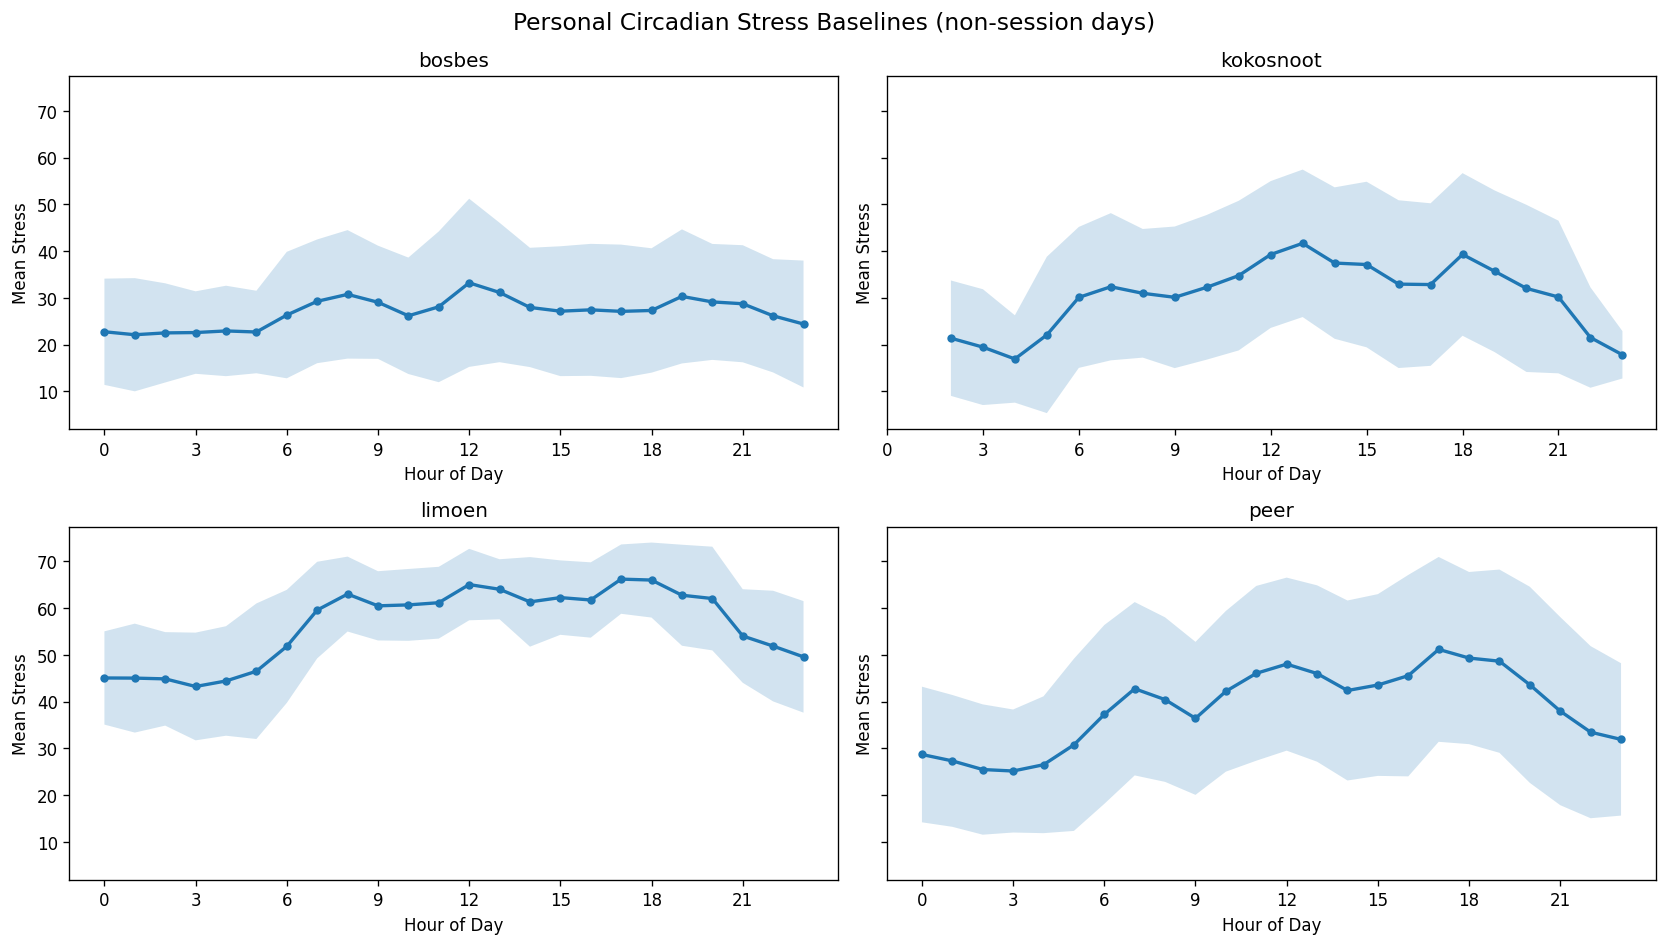

In [2]:
# Plot individual circadian curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=True)
for ax, p in zip(axes.flat, PARTICIPANTS):
    bl_path = ANALYSIS_DIR / p / "circadian_baselines" / "hourly_baseline.csv"
    if bl_path.exists():
        bl = pd.read_csv(bl_path)
        valid = bl["mean_stress"].notna()
        ax.plot(bl["hour"], bl["mean_stress"], "o-", linewidth=2, markersize=4)
        ax.fill_between(
            bl.loc[valid, "hour"],
            bl.loc[valid, "mean_stress"] - bl.loc[valid, "std_stress"],
            bl.loc[valid, "mean_stress"] + bl.loc[valid, "std_stress"],
            alpha=0.2,
        )
        ax.set_title(p)
        ax.set_xticks(range(0, 24, 3))
        ax.set_xlabel("Hour of Day")
        ax.set_ylabel("Mean Stress")
fig.suptitle("Personal Circadian Stress Baselines (non-session days)", fontsize=14)
fig.tight_layout()
plt.show()

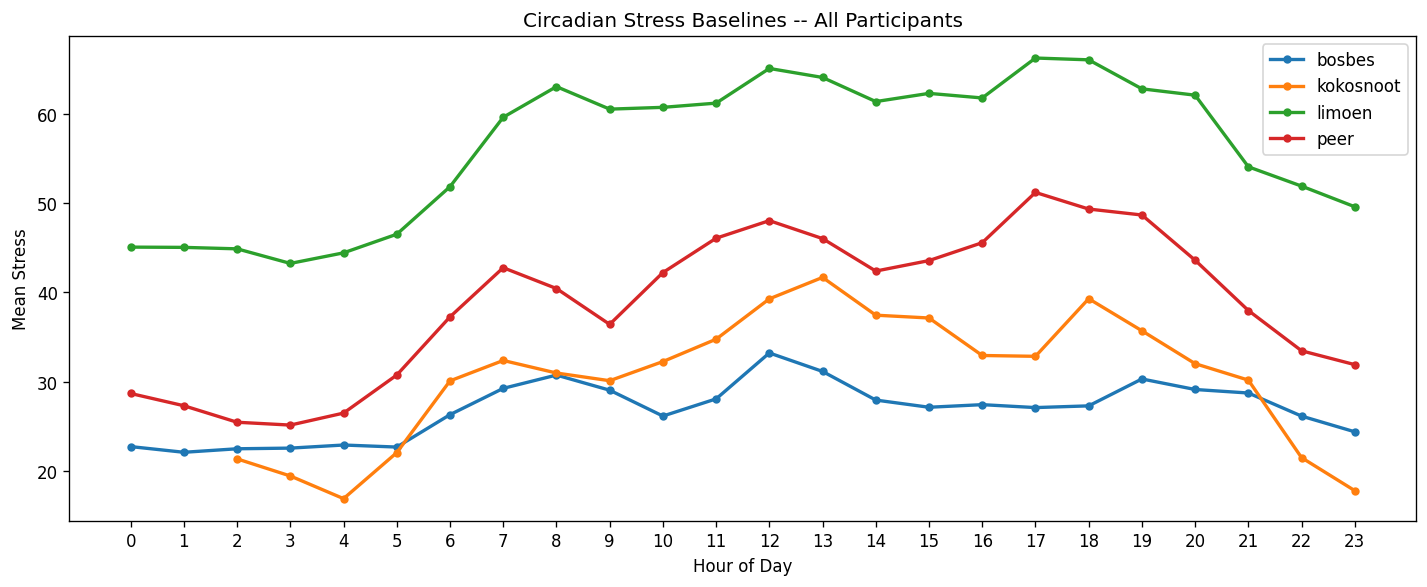

In [3]:
# Overlay comparison
fig, ax = plt.subplots(figsize=(12, 5))
for p in PARTICIPANTS:
    bl_path = ANALYSIS_DIR / p / "circadian_baselines" / "hourly_baseline.csv"
    if bl_path.exists():
        bl = pd.read_csv(bl_path)
        ax.plot(bl["hour"], bl["mean_stress"], "o-", label=p, linewidth=2, markersize=4)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Stress")
ax.set_title("Circadian Stress Baselines -- All Participants")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()
plt.show()

## 2. Feature Matrix Overview

One row per listening session. Features include the circadian baseline deviation, time context, playlist type, mood, and Body Battery. HRV is included in the matrix but excluded from models (only peer has it currently).

In [4]:
fm = pd.read_csv(COMBINED_DIR / "feature_matrix.csv")
print(f"Total sessions: {len(fm)}")
print(f"\nSessions per participant:")
display(fm["participant"].value_counts().to_frame())

print(f"\nNaN counts per column:")
nan_counts = fm.isna().sum()
nan_pct = (fm.isna().mean() * 100).round(1)
nan_df = pd.DataFrame({"NaN count": nan_counts, "NaN %": nan_pct})
display(nan_df[nan_df["NaN count"] > 0])

print(f"\nFeature summary (model inputs):")
display(fm[FEATURE_COLS + ["mood_delta", "stress_delta"]].describe().round(2))

Total sessions: 76

Sessions per participant:


,count
participant,
kokosnoot,34
peer,30
limoen,8
bosbes,4



NaN counts per column:


,NaN count,NaN %
baseline_deviation_entry,36,47.4
hr_baseline_deviation,38,50.0
bb_start,34,44.7
days_since_last_session,4,5.3
hrv_rmssd,46,60.5
avg_resp_daily,33,43.4
pre_state,46,60.5
pre_state_encoded,46,60.5
stress_delta,37,48.7
pre_stress_mean,36,47.4



Feature summary (model inputs):


,baseline_deviation_entry,hr_baseline_deviation,hour_of_day,day_of_week,playlist_calm,playlist_energy,mood_before_score,bb_start,days_since_last_session,during_stress_mean,post_stress_mean,during_hr_mean,post_hr_mean,pre_state_encoded,hrv_rmssd,avg_resp_daily,mood_delta,stress_delta
count,40.00,38.00,76.00,76.00,76.00,76.00,76.00,42.00,72.00,41.00,42.00,35.00,34.00,30.00,30.00,43.00,76.00,39.00
mean,1.63,1.25,11.37,2.33,0.37,0.45,6.68,43.36,4.51,42.66,40.49,84.07,84.40,0.87,26.60,15.77,-0.22,-1.06
std,13.48,8.46,4.23,1.79,0.49,0.50,1.75,22.76,5.03,13.69,12.25,8.90,10.42,0.57,4.30,1.27,2.52,11.90
min,-29.45,-13.93,6.00,0.00,0.00,0.00,3.00,5.00,0.00,11.50,17.70,61.80,66.10,0.00,17.00,13.00,-8.00,-30.60
25%,-8.59,-4.90,7.00,1.00,0.00,0.00,5.00,27.25,1.00,33.90,31.70,79.55,77.62,1.00,23.25,15.00,-2.00,-9.10
50%,1.84,1.30,11.00,2.00,0.00,0.00,6.50,40.50,2.00,41.00,39.15,84.70,84.55,1.00,27.50,16.00,0.00,1.30
75%,6.85,5.56,14.25,4.00,1.00,1.00,8.00,65.00,6.00,50.40,47.40,90.35,89.50,1.00,29.00,17.00,1.00,5.60
max,32.79,28.39,22.00,6.00,1.00,1.00,10.00,81.00,28.00,91.00,68.50,102.20,106.10,3.00,36.00,18.00,7.00,20.60


## 3. Model Results -- Mood Delta

Predicting `mood_delta` (mood_after - mood_before) using leave-one-session-out cross-validation.

Models: Ridge (linear baseline), Random Forest, Gradient Boosting, plus DummyMean (always predicts the mean) as null baseline.

,model,MAE,RMSE,R2_LOO,R2_train_mean,overfit_gap
0,DummyMean,1.904,2.539,-0.027,0.000,0.027
1,Ridge,1.936,2.282,0.171,0.542,0.371
2,RandomForest,1.751,2.232,0.207,0.658,0.451
3,GradientBoosting,1.819,2.287,0.167,0.786,0.619



Model comparison:


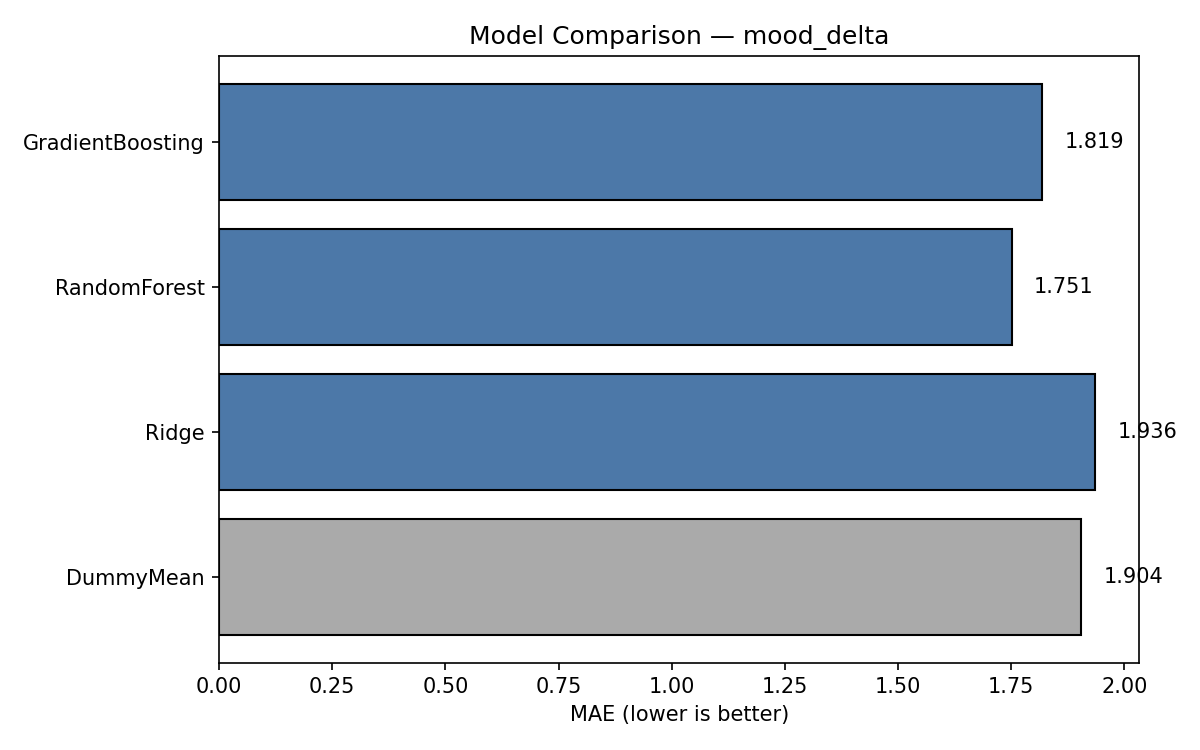


Per-participant MAE (bias check):


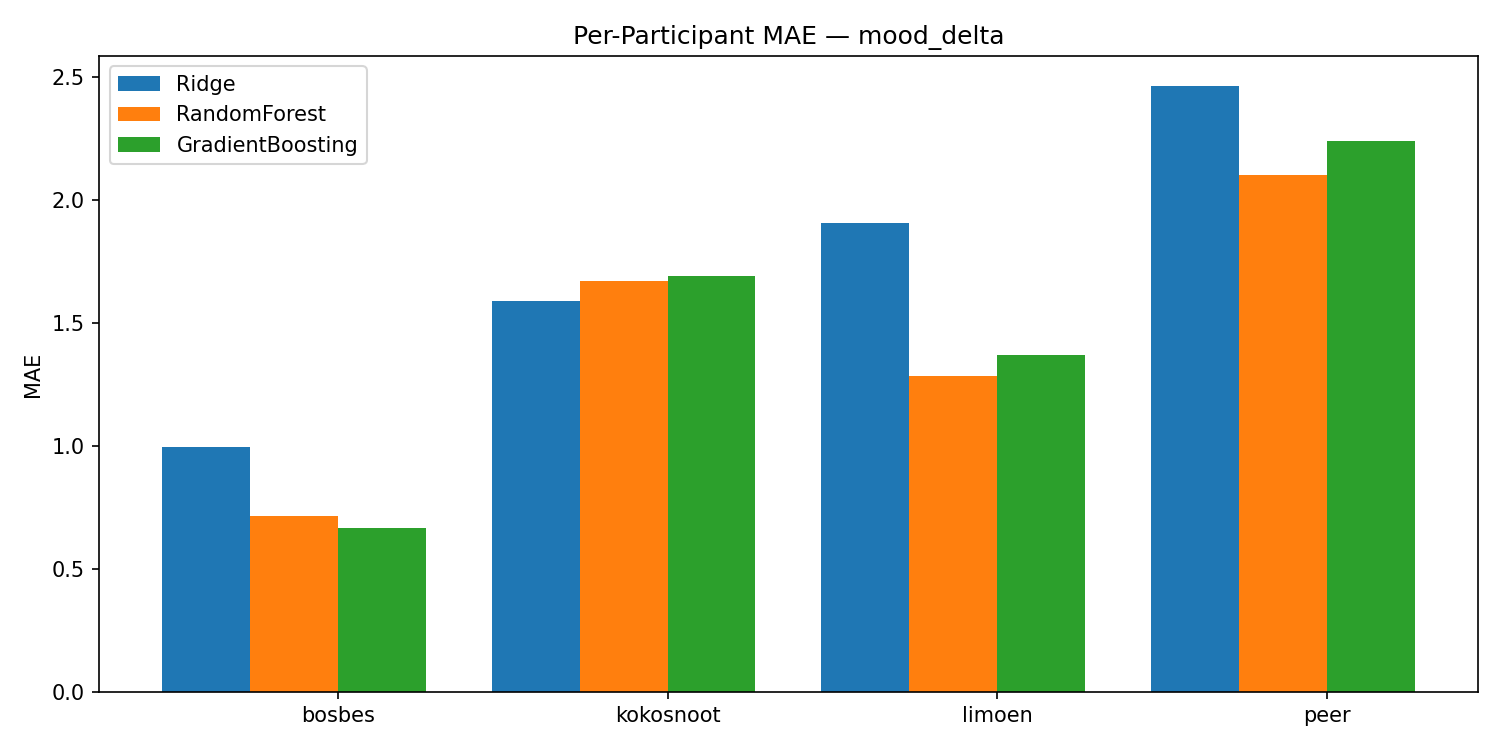


Predicted vs Actual:


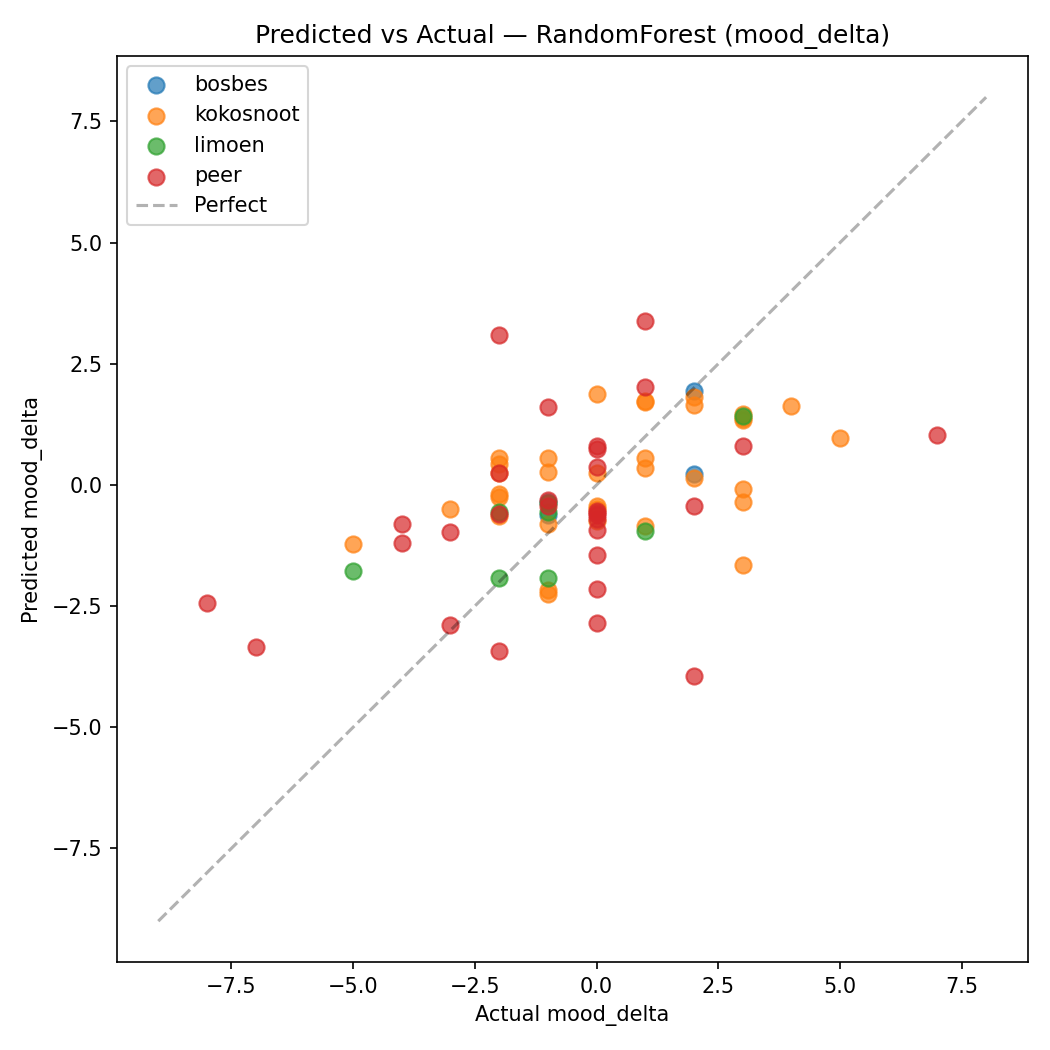

In [5]:
# Load and display model results
mood_results = pd.read_csv(COMBINED_DIR / "model_results_mood_delta.csv")
display(mood_results[["model", "MAE", "RMSE", "R2_LOO", "R2_train_mean", "overfit_gap"]].round(3))

# Show saved plots
from IPython.display import Image
print("\nModel comparison:")
display(Image(filename=str(COMBINED_DIR / "plots" / "model_comparison_mood_delta.png")))

print("\nPer-participant MAE (bias check):")
display(Image(filename=str(COMBINED_DIR / "plots" / "per_participant_mae_mood_delta.png")))

print("\nPredicted vs Actual:")
display(Image(filename=str(COMBINED_DIR / "plots" / "predicted_vs_actual_mood_delta.png")))

## 4. Explainability -- Mood Delta

### Ridge Coefficients
Directional: positive coefficient = feature pushes mood_delta up (more improvement).

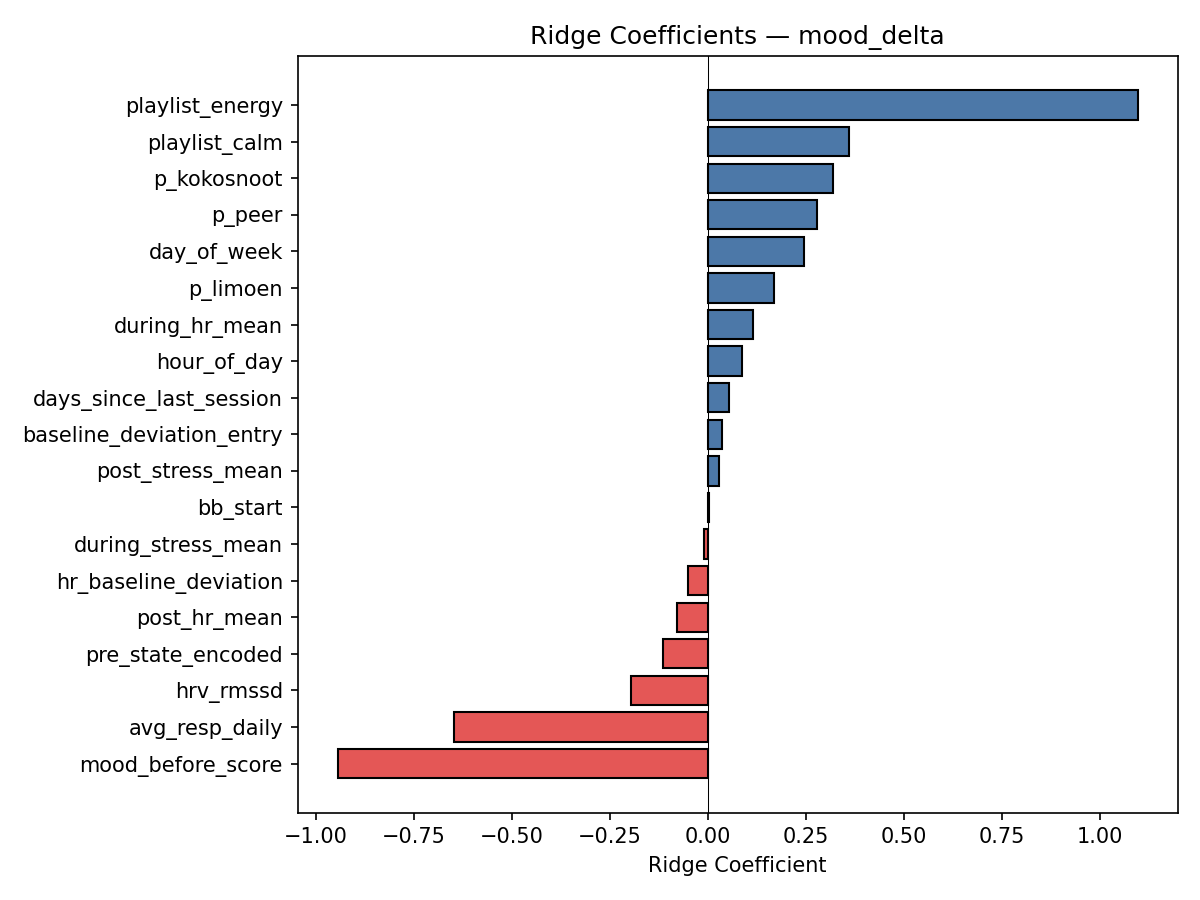

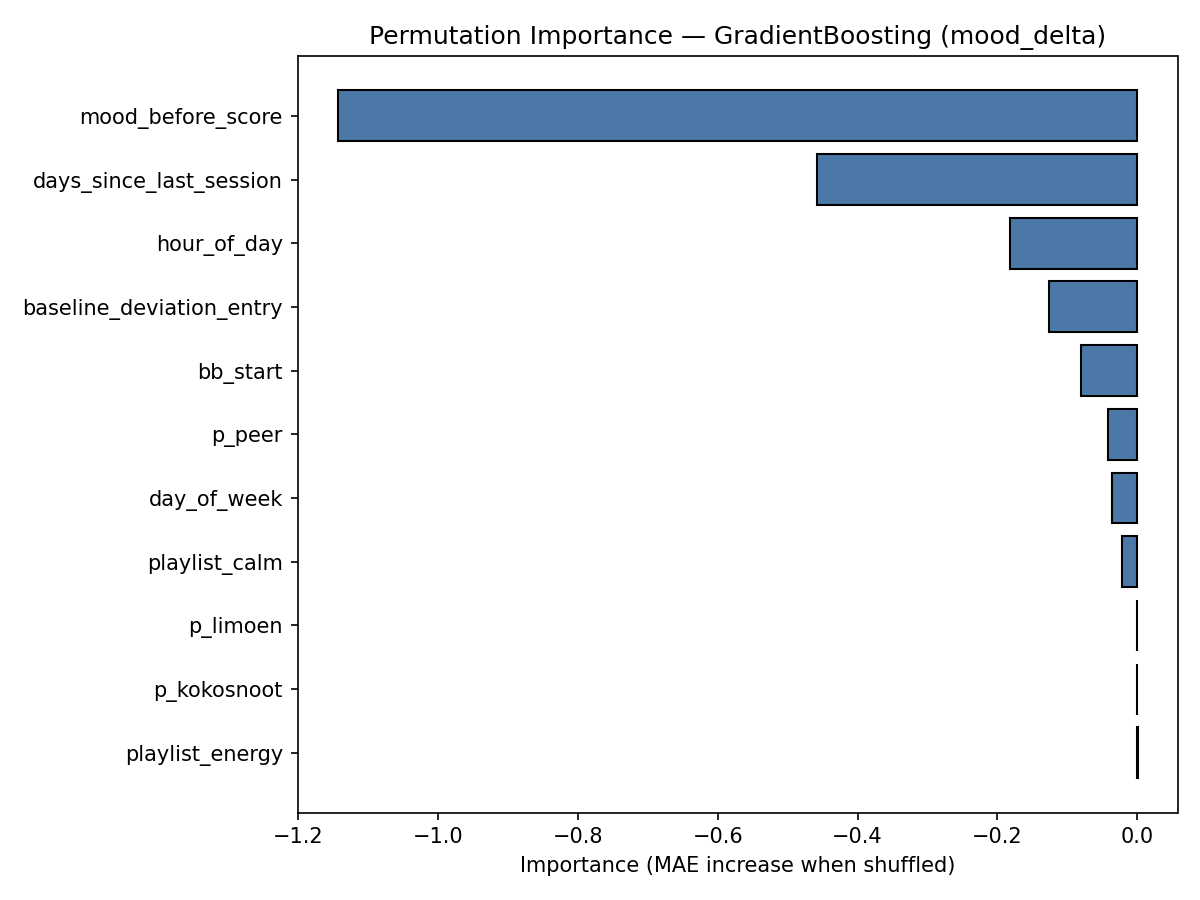

In [6]:
display(Image(filename=str(COMBINED_DIR / "plots" / "ridge_coefficients_mood_delta.png")))
display(Image(filename=str(COMBINED_DIR / "plots" / "permutation_importance_GradientBoosting_mood_delta.png")))

### SHAP -- Combined (all participants)

**Data quality caveat:** SHAP values below are computed on N=52 sessions with significant NaN fractions in stress-based features (63%). The model is being explained, not necessarily reality. Treat as directional only.

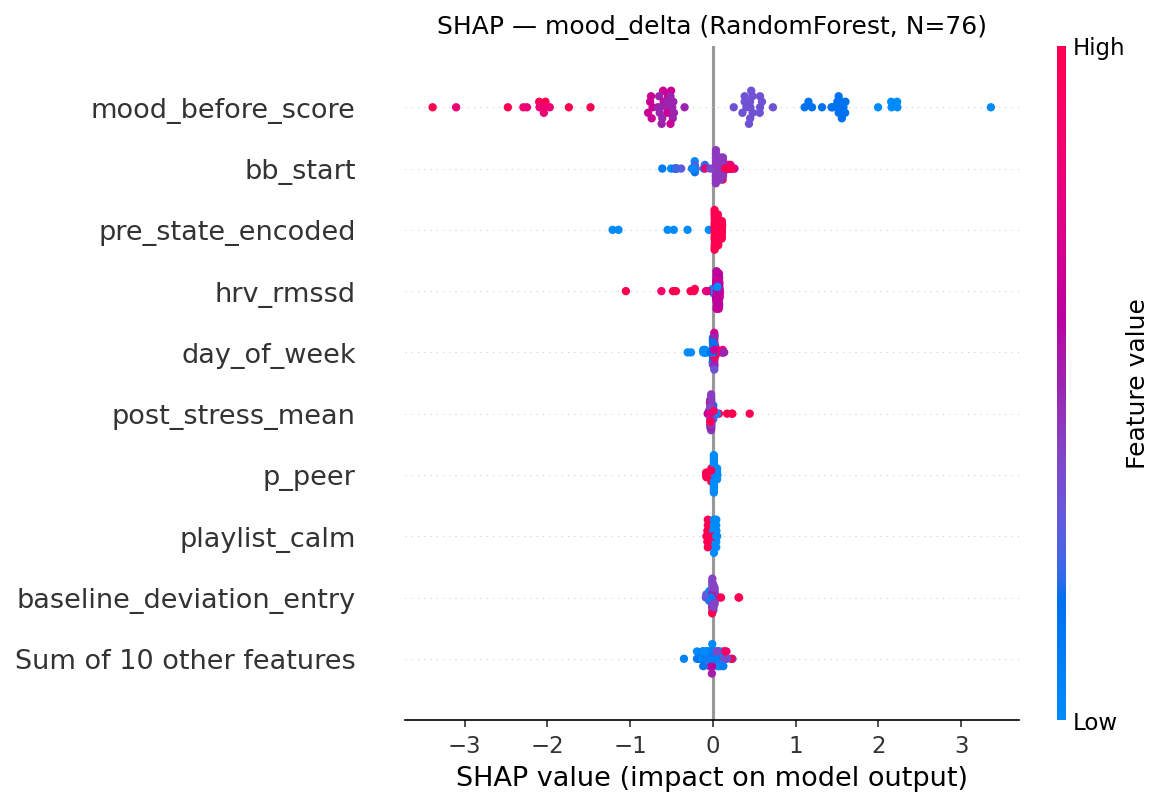

In [7]:
display(Image(filename=str(COMBINED_DIR / "plots" / "shap_mood_delta.png")))

### SHAP -- Per Participant

Run SHAP for a specific participant or subset. Change the `participant_filter` below.

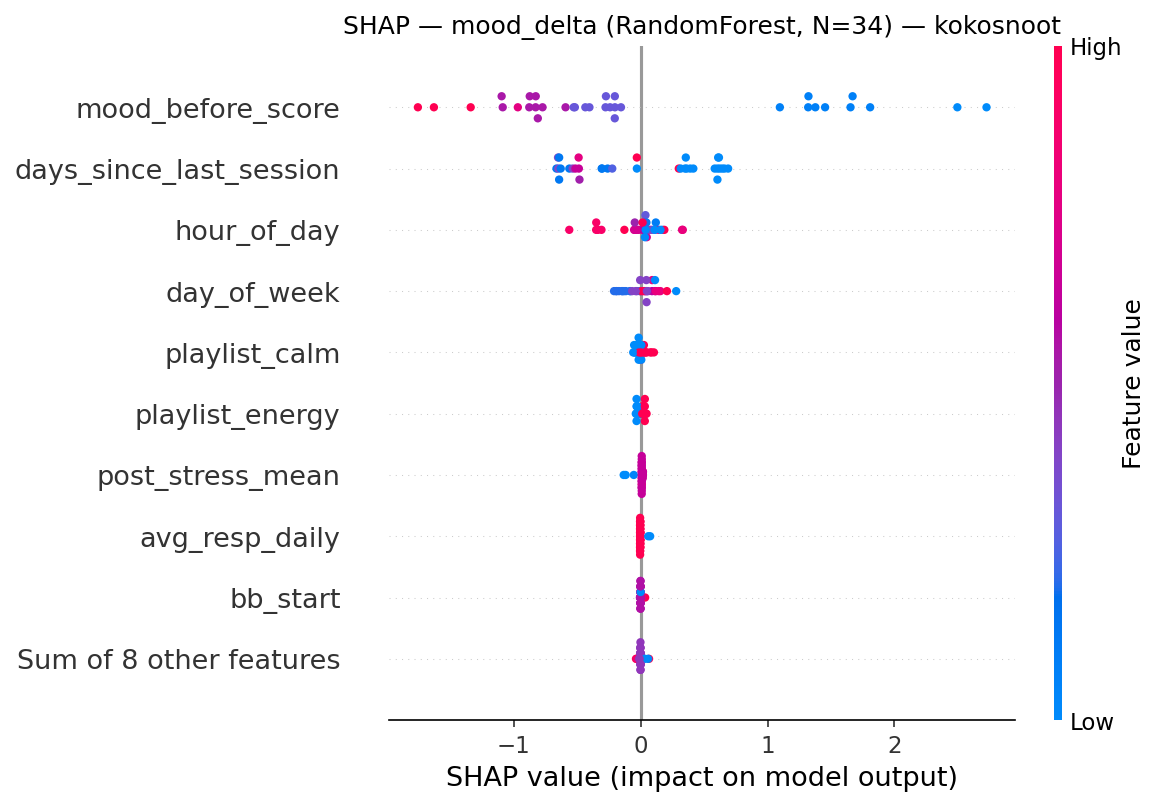

In [8]:
# Change this to run SHAP for a specific participant
participant_filter = "kokosnoot"  # Options: "bosbes", "kokosnoot", "limoen", "peer"

shap_path = ANALYSIS_DIR / participant_filter / "circadian_baselines" / "plots" / f"shap_mood_delta_{participant_filter}.png"
if shap_path.exists():
    display(Image(filename=str(shap_path)))
else:
    # Run SHAP on the fly for this participant
    target = "mood_delta"
    feature_matrix_path = COMBINED_DIR / "feature_matrix.csv"
    X, y, feature_names, groups = prepare_data(feature_matrix_path, target)
    mask = groups == participant_filter
    if mask.sum() >= 3:
        best_model = "GradientBoosting"  # or pick from mood_results
        output_dir = ANALYSIS_DIR / participant_filter / "circadian_baselines" / "plots"
        run_shap(X[mask], y[mask], best_model, target, output_dir, label=participant_filter)
        display(Image(filename=str(output_dir / f"shap_{target}_{participant_filter}.png")))
    else:
        print(f"Not enough sessions for {participant_filter} (need >= 3, have {mask.sum()})")

## 5. Stress Delta Results

Predicting `stress_delta` (post_stress - pre_stress). Only ~18 sessions have this value -- results are underpowered.

,model,MAE,RMSE,R2_LOO,R2_train_mean,overfit_gap
0,DummyMean,9.407,12.056,-0.053,0.000,0.053
1,Ridge,3.648,5.148,0.808,0.959,0.151
2,RandomForest,7.325,9.429,0.356,0.868,0.512
3,GradientBoosting,7.004,8.725,0.448,0.980,0.532



Model comparison:


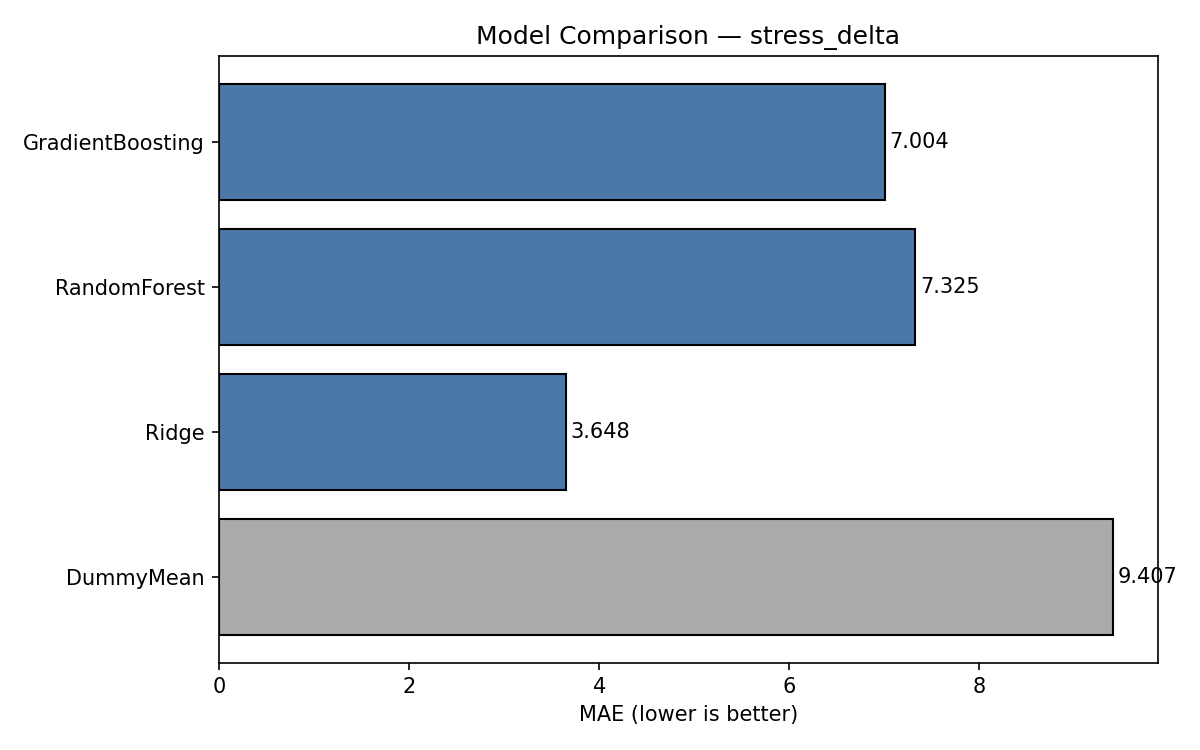


SHAP (N=18, very low reliability):


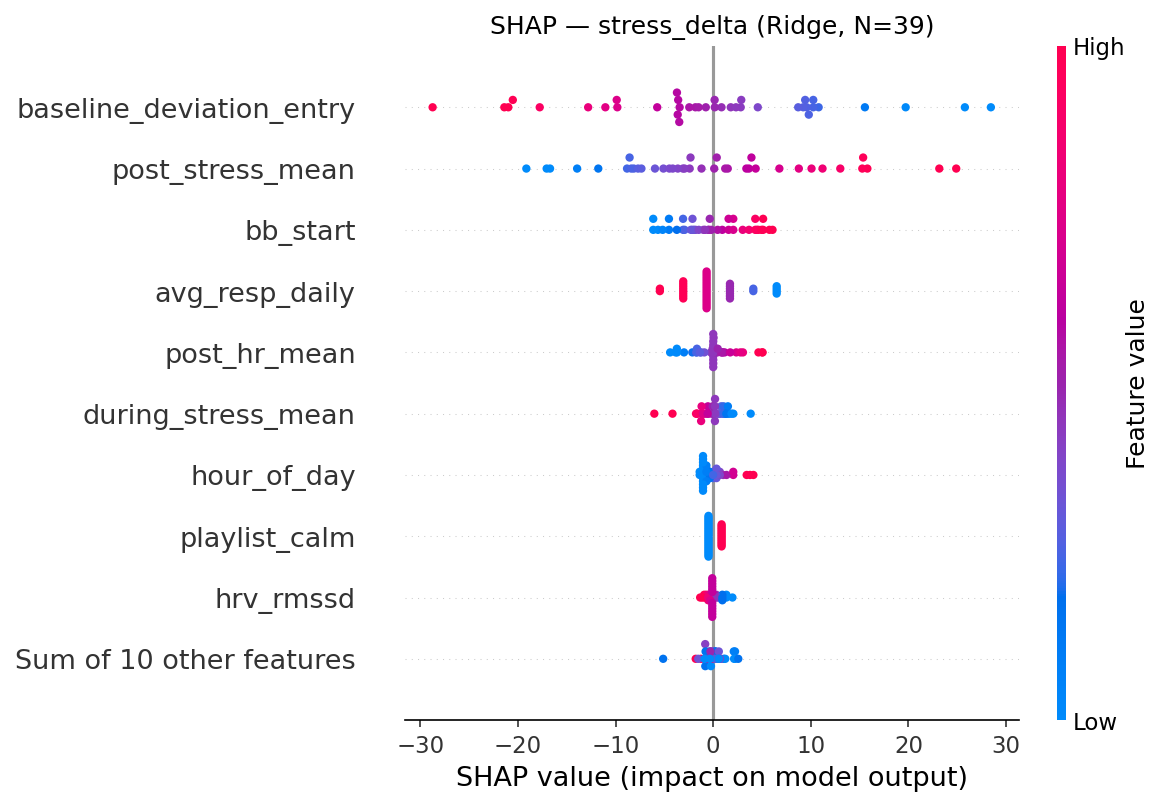

In [9]:
stress_results = pd.read_csv(COMBINED_DIR / "model_results_stress_delta.csv")
display(stress_results[["model", "MAE", "RMSE", "R2_LOO", "R2_train_mean", "overfit_gap"]].round(3))

print("\nModel comparison:")
display(Image(filename=str(COMBINED_DIR / "plots" / "model_comparison_stress_delta.png")))

print("\nSHAP (N=18, very low reliability):")
display(Image(filename=str(COMBINED_DIR / "plots" / "shap_stress_delta.png")))

## 6. Manual Checks (LOPO + mood_before ablation)

These are one-off validation checks not baked into the automated script.

In [10]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# --- LOPO: Leave-One-Participant-Out ---
print("=== Leave-One-Participant-Out (LOPO) ===")
print("Tests if patterns generalize across participants.\n")

target = "mood_delta"
X, y, feature_names, groups = prepare_data(COMBINED_DIR / "feature_matrix.csv", target)
logo = LeaveOneGroupOut()

for model_name, model in MODELS.items():
    if model_name == "DummyMean":
        continue
    preds = np.full(len(y), np.nan)
    for train_idx, test_idx in logo.split(X, y, groups):
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", clone(model)),
        ])
        pipe.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds[test_idx] = pipe.predict(X.iloc[test_idx])
    mae = mean_absolute_error(y, preds)
    print(f"  {model_name}: LOPO MAE = {mae:.3f}")

=== Leave-One-Participant-Out (LOPO) ===
Tests if patterns generalize across participants.

  Ridge: LOPO MAE = 1.920


c:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['pre_state_encoded' 'hrv_rmssd']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['pre_state_encoded' 'hrv_rmssd']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


  RandomForest: LOPO MAE = 1.758
  GradientBoosting: LOPO MAE = 1.922


c:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['pre_state_encoded' 'hrv_rmssd']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['pre_state_encoded' 'hrv_rmssd']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['pre_state_encoded' 'hrv_rmssd']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\.venv\Lib\sit

In [11]:
# --- Ablation: with vs without mood_before_score ---
print("=== mood_before_score Ablation ===")
print("Checks if other features contribute beyond regression-to-mean.\n")

from circadian_ml import run_loo_cv, _clone_model

for include_mood in [True, False]:
    label = "WITH mood_before" if include_mood else "WITHOUT mood_before"
    cols_to_use = list(X.columns)
    if not include_mood:
        cols_to_use = [c for c in cols_to_use if c != "mood_before_score"]
    X_sub = X[cols_to_use]
    
    res = run_loo_cv(X_sub, y, MODELS["GradientBoosting"], cols_to_use)
    print(f"  {label}: MAE={res['MAE']:.3f}, R2_LOO={res['R2_LOO']:.3f}")

=== mood_before_score Ablation ===
Checks if other features contribute beyond regression-to-mean.

  WITH mood_before: MAE=1.819, R2_LOO=0.167
  WITHOUT mood_before: MAE=2.327, R2_LOO=-0.483


## 7. Key Findings

*Fill in after reviewing the results above.*

- **Best model for mood_delta:** ...
- **Most important features:** ...
- **Does baseline deviation matter?** ...
- **Overfitting concerns:** ...
- **Data gaps to address:** Kokosnoot and limoen need fresh wearable exports (stress data stops Feb 2026). HRV only available for peer -- need at least 2 participants before including in models.

## 8. Session Arc & Significance Analysis

**Full arc comparison:** For each session, compare stress and HR at all three windows (pre / during / post) against the participant's personal circadian baseline at that hour. Activity state is classified per window. Body Battery uses absolute delta (no hourly norm).

**Significance tests (thesis-grade):**
- One-sample t-tests (deviation ≠ 0) per metric per window
- Paired t-tests (pre vs post)
- One-way ANOVA by playlist type and by pre-session activity state
- FDR correction (Benjamini–Hochberg), Cohen's d / η², Shapiro–Wilk + Levene's checks
- Bootstrapped 95% CIs (BCa, 1000 resamples)

**Long-term effects:**
- Session-order trend (does the effect improve over time?)
- Rolling 14-day baseline drift (does the personal norm shift?)
- Cumulative exposure (Spearman: more sessions → stronger effect?)
- HRV daily covariate trend (optional, peer only)

**Prerequisite:** Run `python scripts/analysis/pipeline.py` first to generate `classified_minutes.csv` per participant.

In [12]:
from session_arc_analysis import (
    build_arc_deviations, run_significance_tests, compute_long_term_trends,
    plot_arc_per_participant, plot_deviation_heatmap, plot_long_term_trends,
    plot_rolling_baseline, plot_significance_summary, _bootstrap_ci,
    OUTPUT_DIR,
)

# Build arc deviations (or load from CSV if already computed)
arc_path = OUTPUT_DIR / "arc_deviations.csv"
if arc_path.exists():
    arc_df = pd.read_csv(arc_path)
    print(f"Loaded {len(arc_df)} sessions from {arc_path.name}")
else:
    arc_df = build_arc_deviations(PARTICIPANTS)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    arc_df.to_csv(arc_path, index=False)
    print(f"Built {len(arc_df)} sessions")

print(f"\nParticipants: {arc_df['participant'].unique().tolist()}")
print(f"Columns: {len(arc_df.columns)}")
display(arc_df[["participant", "date", "playlist", "pre_state", "during_state", "post_state",
                "stress_dev_pre", "stress_dev_during", "stress_dev_post", "mood_delta"]].head(10))

Loaded 6 sessions from arc_deviations.csv

Participants: ['peer']
Columns: 38


,participant,date,playlist,pre_state,during_state,post_state,stress_dev_pre,stress_dev_during,stress_dev_post,mood_delta
0,peer,2026-01-28,Energy,Medium,Medium,Medium,28.758496,14.158006,19.088922,1.0
1,peer,2026-02-02,Calm,Sleep,Sleep,Sleep,15.408451,3.343935,22.214006,-4.0
2,peer,2026-02-09,Neutral,Sleep,Sleep,Sleep,17.893299,1.595951,3.799755,0.0
3,peer,2026-02-16,Neutral,Sleep,Sleep,Light,-5.230499,12.518392,1.169964,-8.0
4,peer,2026-02-18,Calm,Sleep,Sleep,Sleep,16.741784,2.694165,NaN,-7.0
5,peer,2026-02-24,Energy,Sleep,Sleep,Sleep,25.616784,11.122736,13.453174,2.0


### 8.1 Arc Deviation Plot

Per participant: 3 grouped bars (pre / during / post) for stress and HR. Red = above baseline, blue = below. Error bars = bootstrapped 95% CI.

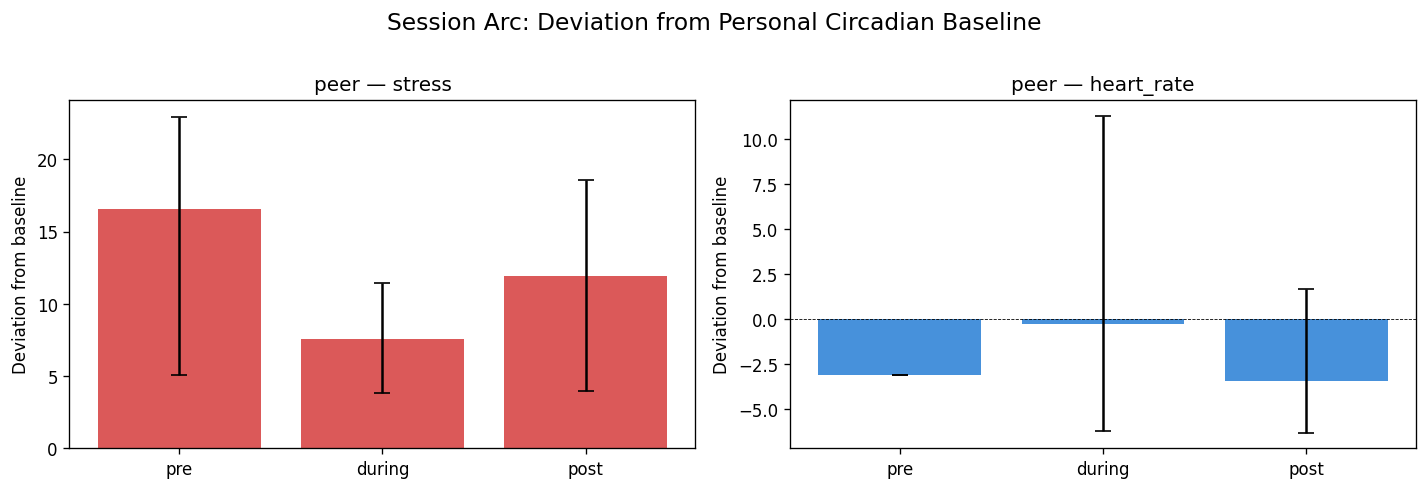

In [13]:
# Arc deviation per participant
participants_in_data = arc_df["participant"].unique()
signals = ["stress", "heart_rate"]
windows = ["pre", "during", "post"]

fig, axes = plt.subplots(
    len(participants_in_data), len(signals),
    figsize=(12, 4 * len(participants_in_data)),
    squeeze=False,
)

for i, participant in enumerate(participants_in_data):
    pdata = arc_df[arc_df["participant"] == participant]
    for j, signal in enumerate(signals):
        ax = axes[i, j]
        means, errs = [], []
        for w in windows:
            col = f"{signal}_dev_{w}"
            if col not in pdata.columns:
                means.append(0)
                errs.append((0, 0))
                continue
            vals = pdata[col].dropna()
            m = float(vals.mean()) if len(vals) > 0 else 0.0
            means.append(m)
            if len(vals) >= 3:
                lo, hi = _bootstrap_ci(vals.values)
                errs.append((m - lo, hi - m))
            else:
                errs.append((0, 0))

        colors = ["#d32f2f" if m > 0 else "#1976d2" for m in means]
        yerr = np.array(errs).T
        ax.bar(windows, means, color=colors, yerr=yerr, capsize=5, alpha=0.8)
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
        ax.set_title(f"{participant} — {signal}")
        ax.set_ylabel("Deviation from baseline")

fig.suptitle("Session Arc: Deviation from Personal Circadian Baseline", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### 8.2 Session × Window Heatmap

Each row is one session (sorted by participant + date). Columns show deviations for stress and HR across pre/during/post. Red = above baseline, blue = below.

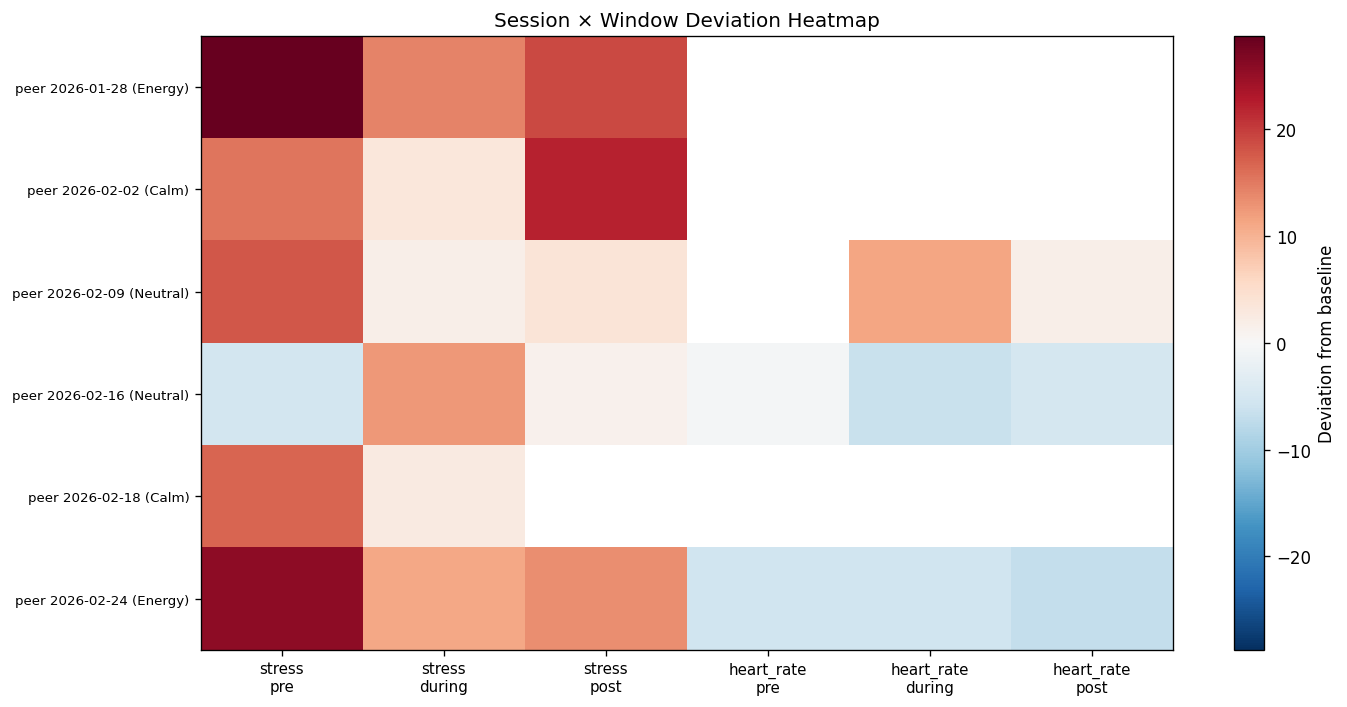

In [14]:
# Session × Window deviation heatmap
dev_cols = [c for c in [
    "stress_dev_pre", "stress_dev_during", "stress_dev_post",
    "heart_rate_dev_pre", "heart_rate_dev_during", "heart_rate_dev_post",
] if c in arc_df.columns]

if dev_cols:
    plot_df = arc_df.sort_values(["participant", "date"]).reset_index(drop=True)
    labels = plot_df.apply(lambda r: f"{r['participant'][:4]} {r['date']} ({r['playlist']})", axis=1)

    data = plot_df[dev_cols].values.astype(float)
    vmax = max(abs(np.nanmin(data)), abs(np.nanmax(data)), 1)

    fig, ax = plt.subplots(figsize=(12, max(6, len(plot_df) * 0.5)))
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xticks(range(len(dev_cols)))
    ax.set_xticklabels([c.replace("_dev_", "\n") for c in dev_cols], fontsize=9)
    plt.colorbar(im, label="Deviation from baseline")
    ax.set_title("Session × Window Deviation Heatmap")
    fig.tight_layout()
    plt.show()
else:
    print("No deviation columns found in arc_df")

### 8.3 Long-term Trend Lines

Session number on x-axis, post-session stress deviation and mood delta on y-axis. Per-participant regression lines + pooled trend with p-value.

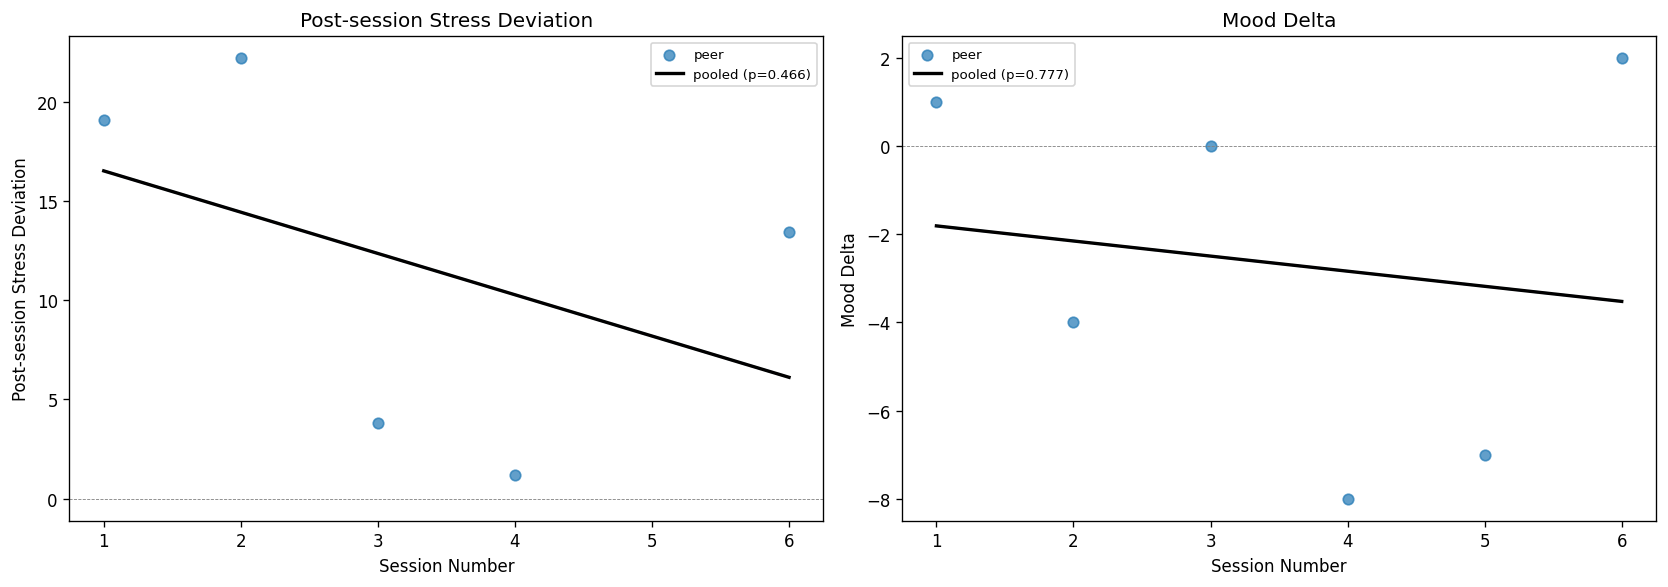

In [15]:
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, label) in zip(axes, [
    ("stress_dev_post", "Post-session Stress Deviation"),
    ("mood_delta", "Mood Delta"),
]):
    if col not in arc_df.columns:
        continue

    for participant in arc_df["participant"].unique():
        pdata = arc_df[arc_df["participant"] == participant].sort_values("session_number")
        valid = pdata[["session_number", col]].dropna()
        if valid.empty:
            continue
        ax.scatter(valid["session_number"], valid[col], label=participant, alpha=0.7, s=40)
        if len(valid) >= 3:
            slope, intercept, *_ = sp_stats.linregress(valid["session_number"], valid[col])
            x_line = np.array([valid["session_number"].min(), valid["session_number"].max()])
            ax.plot(x_line, slope * x_line + intercept, "--", alpha=0.5)

    # Pooled trend
    valid_all = arc_df[["session_number", col]].dropna()
    if len(valid_all) >= 3:
        slope, intercept, _, p, _ = sp_stats.linregress(valid_all["session_number"], valid_all[col])
        x_line = np.array([valid_all["session_number"].min(), valid_all["session_number"].max()])
        ax.plot(x_line, slope * x_line + intercept, "k-", linewidth=2, label=f"pooled (p={p:.3f})")

    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Session Number")
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

### 8.4 Rolling Baseline Drift

Does the participant's personal stress norm shift over the course of the study? Computed from the last 14 non-session days before each session (falls back to global baseline if < 14 days available).

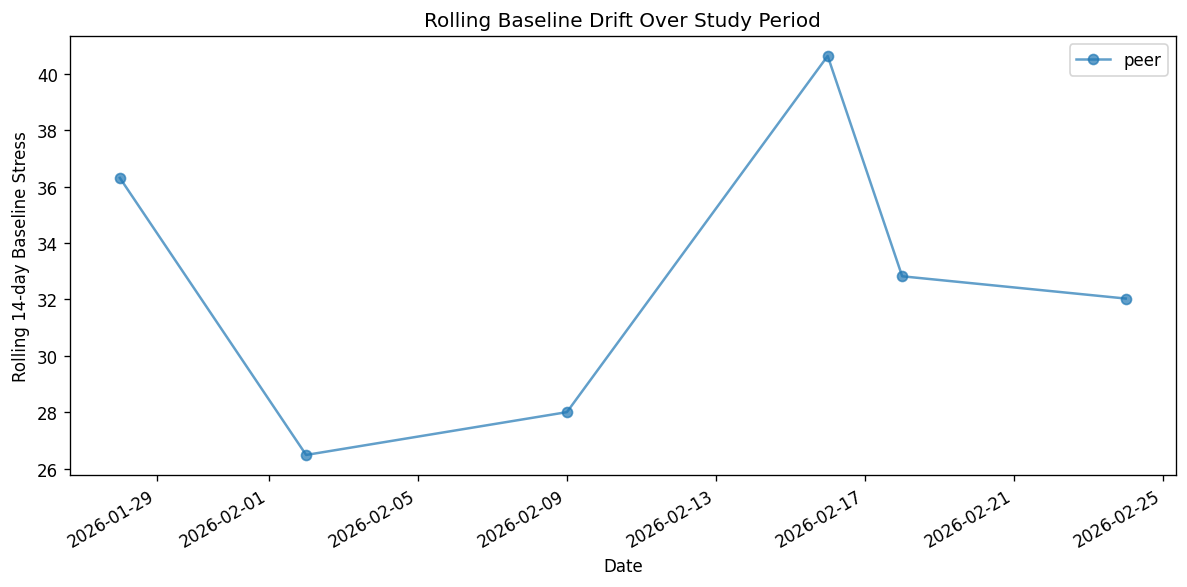

Rolling baseline days available per session:


'participant       date  session_number  rolling_n_days  rolling_baseline_stress_pre  rolling_stress_dev_pre\n       peer 2026-01-28               1              30                    36.306122               30.735544\n       peer 2026-02-02               2              34                    26.490260               21.509740\n       peer 2026-02-09               3              40                    28.007246               22.477602\n       peer 2026-02-16               4              46                    40.628521               -1.812195\n       peer 2026-02-18               5              47                    32.820741               16.512593\n       peer 2026-02-24               6              52                    32.031977               26.176357'

In [16]:
# Rolling baseline drift
if "rolling_baseline_stress_pre" in arc_df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    for participant in arc_df["participant"].unique():
        pdata = arc_df[arc_df["participant"] == participant].sort_values("date")
        valid = pdata[["date", "rolling_baseline_stress_pre", "rolling_n_days"]].dropna(subset=["rolling_baseline_stress_pre"])
        if valid.empty:
            continue
        dates = pd.to_datetime(valid["date"])
        ax.plot(dates, valid["rolling_baseline_stress_pre"], "o-", label=participant, alpha=0.7)

    ax.set_xlabel("Date")
    ax.set_ylabel("Rolling 14-day Baseline Stress")
    ax.set_title("Rolling Baseline Drift Over Study Period")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

    # Show rolling days available per session
    print("Rolling baseline days available per session:")
    display(arc_df[["participant", "date", "session_number", "rolling_n_days",
                     "rolling_baseline_stress_pre", "rolling_stress_dev_pre"]].dropna(
        subset=["rolling_baseline_stress_pre"]).to_string(index=False))
else:
    print("No rolling baseline data — run session_arc_analysis.py first")

### 8.5 Significance Summary Table

All tests with raw p-value, FDR-corrected q-value, effect size, and assumption check flags. Color-coded: green (q < 0.05), yellow (q < 0.10), red (q ≥ 0.10).

In [17]:
# Run significance tests
sig_path = OUTPUT_DIR / "significance_results.csv"
if sig_path.exists():
    sig_df = pd.read_csv(sig_path)
    print(f"Loaded {len(sig_df)} test results")
else:
    sig_df = run_significance_tests(arc_df)
    sig_df.to_csv(sig_path, index=False)
    print(f"Computed {len(sig_df)} test results")

n_sig = int((sig_df["q_value"] < 0.05).sum()) if not sig_df.empty else 0
n_marginal = int(((sig_df["q_value"] >= 0.05) & (sig_df["q_value"] < 0.1)).sum()) if not sig_df.empty else 0
print(f"  Significant (q < 0.05): {n_sig}")
print(f"  Marginal (0.05 ≤ q < 0.10): {n_marginal}")

# Display styled table (exclude Tukey pairwise for readability)
main_tests = sig_df[~sig_df["test_name"].str.contains("tukey")].copy()

def color_q(val):
    if pd.isna(val):
        return ""
    if val < 0.05:
        return "background-color: #c8e6c9"  # green
    elif val < 0.10:
        return "background-color: #fff9c4"  # yellow
    else:
        return "background-color: #ffcdd2"  # red

display_cols = ["test_name", "metric", "window", "n", "mean", "ci_low", "ci_high",
                "statistic", "p_value", "q_value", "effect_size", "effect_size_type",
                "normality_ok", "equal_variance_ok"]
display_cols = [c for c in display_cols if c in main_tests.columns]

styled = (
    main_tests[display_cols]
    .style
    .applymap(color_q, subset=["q_value"])
    .format({
        "mean": "{:.2f}", "ci_low": "{:.2f}", "ci_high": "{:.2f}",
        "statistic": "{:.3f}", "p_value": "{:.4f}", "q_value": "{:.4f}",
        "effect_size": "{:.3f}",
    }, na_rep="—")
)
display(styled)

Loaded 26 test results
  Significant (q < 0.05): 0
  Marginal (0.05 ≤ q < 0.10): 1


AttributeError: The '.style' accessor requires jinja2

In [ ]:
# Tukey HSD pairwise comparisons (if any)
tukey_tests = sig_df[sig_df["test_name"].str.contains("tukey")]
if not tukey_tests.empty:
    print("Tukey HSD Pairwise Comparisons:")
    display(tukey_tests[["test_name", "metric", "window", "group", "mean", "ci_low", "ci_high", "p_value"]].round(4))
else:
    print("No Tukey HSD comparisons (need ≥2 groups with ≥2 observations each)")

: 

### 8.6 Assumption Checks

QQ-plots and residual histograms for the main deviation metrics. Normality violations are flagged in the significance table above (`normality_ok = False`).

In [ ]:
# QQ-plots and histograms for assumption checking
check_cols = [c for c in [
    "stress_dev_pre", "stress_dev_during", "stress_dev_post",
    "heart_rate_dev_pre", "heart_rate_dev_during", "heart_rate_dev_post",
    "mood_delta", "bb_delta",
] if c in arc_df.columns]

n_cols = len(check_cols)
if n_cols > 0:
    fig, axes = plt.subplots(n_cols, 2, figsize=(10, 3 * n_cols), squeeze=False)

    for i, col in enumerate(check_cols):
        vals = arc_df[col].dropna().values
        if len(vals) < 3:
            axes[i, 0].text(0.5, 0.5, f"N={len(vals)} (too few)", ha="center", va="center")
            axes[i, 1].text(0.5, 0.5, f"N={len(vals)} (too few)", ha="center", va="center")
            continue

        # QQ-plot
        sp_stats.probplot(vals, dist="norm", plot=axes[i, 0])
        axes[i, 0].set_title(f"QQ: {col} (N={len(vals)})")

        # Histogram
        axes[i, 1].hist(vals, bins=min(15, len(vals)), alpha=0.7, edgecolor="black")
        axes[i, 1].set_title(f"Hist: {col}")
        axes[i, 1].axvline(0, color="red", linestyle="--", alpha=0.5)

        # Shapiro-Wilk p-value annotation
        _, sw_p = sp_stats.shapiro(vals)
        flag = "PASS" if sw_p >= 0.05 else "FAIL"
        axes[i, 1].annotate(f"Shapiro p={sw_p:.3f} ({flag})",
                            xy=(0.95, 0.95), xycoords="axes fraction",
                            ha="right", va="top", fontsize=9,
                            color="green" if sw_p >= 0.05 else "red")

    fig.suptitle("Assumption Checks: Normality of Deviations", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("No deviation columns to check")

: 

### 8.7 Long-term Trends Summary

Session-order trends, rolling baseline drift, cumulative exposure, and HRV daily trends.

In [ ]:
# Long-term trends
trends_path = OUTPUT_DIR / "long_term_trends.csv"
if trends_path.exists():
    trends_df = pd.read_csv(trends_path)
    print(f"Loaded {len(trends_df)} trend analyses")
else:
    trends_df = compute_long_term_trends(arc_df)
    trends_df.to_csv(trends_path, index=False)
    print(f"Computed {len(trends_df)} trend analyses")

if not trends_df.empty:
    for analysis_type in trends_df["analysis"].unique():
        subset = trends_df[trends_df["analysis"] == analysis_type]
        print(f"\n{'='*50}")
        print(f"  {analysis_type.replace('_', ' ').title()}")
        print(f"{'='*50}")
        display(subset[["participant", "metric", "slope", "r_squared", "p_value", "n"]].round(4))
else:
    print("No trend data available")

: 